In [1]:
from pathlib import Path

def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise SystemExit("ไม่พบโฟลเดอร์ datasets/ — เปิด JupyterLab จาก repo root (uv run jupyter lab)")

DATA = data_dir()

# Module 2 — Feature Engineering & Data Preparation

**Dataset ที่ใช้ในโมดูลนี้ (โปรดอ่านก่อนใช้งาน):**

- *Combined Cycle Power Plant* — Tüfekci, P. & Kaya, H. (2014). UCI Machine Learning Repository. https://doi.org/10.24432/C5002N (CC BY 4.0) — 9,568 จุดวัดจากโรงไฟฟ้าพลังงานความร้อนร่วม: `AT` (ambient temperature, °C), `V` (exhaust vacuum, cmHg), `AP` (ambient pressure, mbar), `RH` (relative humidity, %) → `PE` (net electrical output, MW)
- *Air Quality* — De Vito, S., et al. (2008). UCI ML Repository. https://doi.org/10.24432/C59K5F (CC BY 4.0) — ใช้สาธิตการจัดการค่าหาย

ไฟล์: `datasets/ccpp_power_plant.csv`, `datasets/air_quality_uci.csv`

## 1. ทำไม feature ถึงสำคัญกว่าโมเดล

ความจริงที่คนทำ ML ย้ำกันเสมอ: **โมเดลที่ดีมาจากข้อมูลที่เข้าใจถูก ไม่ใช่อัลกอริทึมที่แพงที่สุด** การเตรียม feature คือขั้นที่กินเวลาผู้สอนงานจริงมากที่สุด (~70–80%) และเป็นขั้นที่องค์ความรู้ด้านเมโทรโลยีของคุณมีค่าที่สุด — คนรู้ว่าเซนเซอร์ชนิดไหนอ่อนไหวต่ออุณหภูมิ รู้ว่าค่า -9999 แปลว่า "เครื่องพัง" ไม่ใช่ "อุณหภูมิติดลบมาก"

หัวข้อของโมดูลนี้ ไล่ตามลำดับที่ควรทำจริง:

```text
แบ่ง train/test ก่อน  →  จัดการค่าหาย  →  แปลงชนิด (scale/encode)  →  สร้าง feature ใหม่
ทั้งหมดรวมเป็น Pipeline เดียวเพื่อกัน leakage
```

In [2]:
import polars as pl
import numpy as np

ccpp = pl.read_csv(DATA / "ccpp_power_plant.csv")
print(ccpp.shape, "| columns:", ccpp.columns)

(9568, 5) | columns: ['AT', 'V', 'AP', 'RH', 'PE']


## 2. แบ่งข้อมูลก่อน — ทุกอย่างที่เรียนต่อจากนี้ใช้ train เท่านั้น

In [3]:
from sklearn.model_selection import train_test_split

X = ccpp.select("AT", "V", "AP", "RH")
y = ccpp["PE"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"train {len(X_train)} | test {len(X_test)}")

train 7654 | test 1914


## 3. จัดการค่าหาย — เห็นของจริงจาก Air Quality

CCPP ไม่มีค่าหาย แต่ Air Quality มี (คอลัมน์ GT หาย ~18%) — เราใช้ชุดนี้สาธิต

In [4]:
aq = pl.read_csv(
    DATA / "air_quality_uci.csv",
    separator=";",
    null_values="-200",
)
# แปลงทศนิยมแบบ comma → float (เทคนิคเดียวกับโมดูลที่แล้ว)
decimal_cols = [c for c, d in aq.schema.items() if d == pl.String and c not in ("Date", "Time")]
aq = aq.with_columns(
    [pl.col(c).str.replace(",", ".", literal=True).cast(pl.Float64).replace(-200.0, None) for c in decimal_cols]
)
cols = ["CO(GT)", "PT08.S1(CO)", "T", "RH"]
subset = aq.select(cols).drop_nulls()
print(f"เต็ม: {len(aq)} แถว | ไม่มีค่าหาย: {len(subset)} แถว → ตัดแถวเสียข้อมูลไป {len(aq) - len(subset)} แถว (~{(1 - len(subset)/len(aq))*100:.0f}%)")

เต็ม: 9471 แถว | ไม่มีค่าหาย: 7344 แถว → ตัดแถวเสียข้อมูลไป 2127 แถว (~22%)


ทางเลือกของการจัดการค่าหาย:

| วิธี | ใช้เมื่อ | เสี่ยง |
|---|---|---|
| **ตัดแถว** (drop) | ค่าหายน้อย สุ่มกระจาย | ตัดข้อมูลที่อาจมีลายเซ็นสำคัญทิ้ง |
| **เติมค่าคงที่** (median/most_frequent) | ค่าหายกระจายปกติ | บีบความแปรปรวนลง |
| **เติมด้วยสถิติของแถวข้างเคียง** (interpolate) | ข้อมูล time series | มันจะวาดได้ทั้งที่จริงไม่รู้ |
| **เติมด้วยโมเดล** (KNN/mice) | ข้อมูลสัมพันธ์กันแรง | ยุ่ง แต่เป็นธรรมที่สุด |

**กฎเมโทรโลยี:** ค่าหายของช่องสัญญาณวัดมักมีเหตุ (probe หลุด, เครื่องซ่อม) — ถาม "หายอย่างมีแบบแผนไหม" ก่อนเสมอ

In [5]:
# ทางเลือก b: เติมค่าด้วย SimpleImputer ของ scikit-learn
# สร้างชุดข้อมูลที่มีรูเพื่อเห็นผล (จำลอง: ตัดค่าสุ่ม 10% ออกจากคอลัมน์ T)
rng = np.random.default_rng(42)
with_holes = aq.select("PT08.S1(CO)", "T", "RH").with_columns(
    pl.when(pl.Series(rng.random(len(aq))) < 0.10).then(None).otherwise(pl.col("T")).alias("T")
)
print("ค่าหายใน T:", with_holes["T"].null_count(), "จาก", len(with_holes))

ค่าหายใน T: 1360 จาก 9471


In [6]:
from sklearn.impute import SimpleImputer

pdf = with_holes.to_pandas()
imp = SimpleImputer(strategy="median").fit(pdf[["T"]])          # เรียน median จากข้อมูลที่มี
filled = imp.transform(pdf[["T"]])
print(f"median ที่เรียนได้: {imp.statistics_[0]:.2f} °C")
print(f"ค่าหายหลังเติม: {np.isnan(filled).sum()}")

median ที่เรียนได้: 17.70 °C
ค่าหายหลังเติม: 0


## 4. Scaling — ทำให้ทุก feature ใช้สเกลเดียวกัน

ค่า `AT` อยู่ราว 2–37, `AP` ราว 993–1033 — คนละสเกลหลายเท่า โมเดลที่วัด "ระยะทาง" หรือมี regularization (KNN, SVM, ridge/lasso, PCA, neural net) จะโดนคอลัมน์สเกลใหญ่บังคอลัมน์เล็ก

วิธีมาตรฐาน: **standardization** — หัก mean แล้วหารด้วย std ให้ทุกคอลัมน์เฉลี่ย 0, std 1

In [7]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler().fit(X_train)          # เรียน mean/std จาก train เท่านั้น!
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)             # ใช้ mean/std ของ train กับ test ด้วย

print("mean/std ของ AT ก่อน scale:", round(X_train["AT"].mean(), 2), round(X_train["AT"].std(), 2))
print("mean/std ของ AT หลัง scale:", round(X_train_s[:, 0].mean(), 3), round(X_train_s[:, 0].std(), 3))

mean/std ของ AT ก่อน scale: 19.62 7.43
mean/std ของ AT หลัง scale: -0.0 1.0


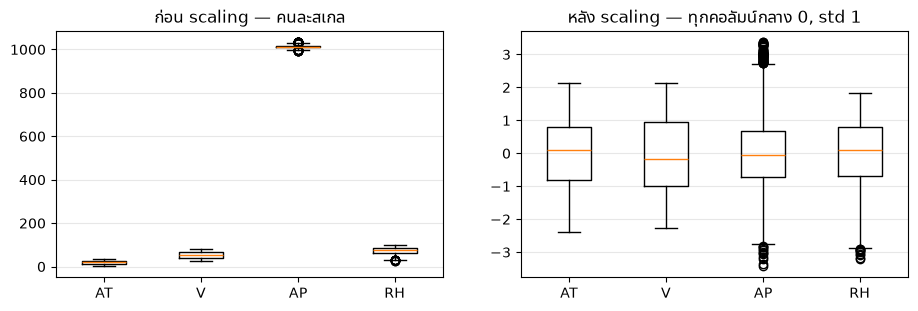

In [8]:
# เห็นภาพก่อน/หลัง scaling
import matplotlib.pyplot as plt
# ฟอนต์ไทยสำหรับป้ายกราฟ — fallback list รองรับทุกแพลตฟอร์ม (macOS/Windows)
plt.rcParams["font.family"] = ["DejaVu Sans", "Noto Sans Thai", "Leelawadee UI", "Tahoma", "Thonburi"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=False)
axes[0].boxplot([X_train[c].to_numpy() for c in ["AT", "V", "AP", "RH"]], tick_labels=["AT", "V", "AP", "RH"])
axes[0].set_title("ก่อน scaling — คนละสเกล")
axes[1].boxplot([X_train_s[:, i] for i in range(4)], tick_labels=["AT", "V", "AP", "RH"])
axes[1].set_title("หลัง scaling — ทุกคอลัมน์กลาง 0, std 1")
for ax in axes:
    ax.grid(axis="y", alpha=0.3)
plt.show()

## 5. ประเภทข้อมูล: ตัวเลข vs หมวดหมู่ (categorical)

CCPP ล้วนตัวเลข แต่งานจริงมักมีข้อมูลหมวดหมู่ — เช่น `sensor_id`, `calibration_batch`, `shift` โมเดลส่วนใหญ่กิน "ตัวเลข" ไม่กิน "ข้อความ" จึงต้องแปลง

กฎ: **nominal** (ไม่มีลำดับ เช่น รุ่นเครื่อง) → OneHotEncoder; **ordinal** (มีลำดับ เช่น เกรดคุณภาพ) → ใช้จำนวนเรียงได้

In [9]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# ตัวอย่างเล็ก ๆ: ค่าที่อ่านจากเซนเซอร์ 3 รุ่น
toy = pl.DataFrame({
    "sensor_id": ["S1", "S2", "S3", "S1", "S2"],
    "mv": [12.1, 11.8, 13.0, 12.3, 11.9],
})
enc = OneHotEncoder(sparse_output=False).fit(toy[["sensor_id"]].to_pandas())
encoded = pl.from_pandas(pd.DataFrame(enc.transform(toy[["sensor_id"]].to_pandas()), columns=enc.get_feature_names_out()))
pl.concat([toy, encoded], how="horizontal")

/tmp/ipykernel_71846/3595020390.py:11: DeprecationWarning: the default behavior of `how='horizontal'` for `concat` is deprecated and will require equal heights in the next breaking release. Use `how='horizontal_extend'` to keep the current behavior.
(Deprecated in version 1.42.1)
  pl.concat([toy, encoded], how="horizontal")


sensor_id,mv,sensor_id_S1,sensor_id_S2,sensor_id_S3
str,f64,f64,f64,f64
"""S1""",12.1,1.0,0.0,0.0
"""S2""",11.8,0.0,1.0,0.0
"""S3""",13.0,0.0,0.0,1.0
"""S1""",12.3,1.0,0.0,0.0
"""S2""",11.9,0.0,1.0,0.0


## 6. สร้าง feature ใหม่ — ที่ซึ่งความรู้เมโทรโลยีเข้ามาเล่น

วิธีพื้นฐาน 3 กลุ่ม:
1. **Polynomial** — ความสัมพันธ์โค้ง (AT² สำหรับผลของอุณหภูมิ)
2. **Interaction** — ผลร่วมของสองตัวแปร (AT×RH: อุณหภูมิร้อนชื้นต่างจากร้อนแห้ง)
3. **Domain knowledge** — ตรงจากฟิสิกส์ของระบบ (เช่น อุณหภูมิจุดน้ำค้างจาก T และ RH)

In [10]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_train[:5])
print("ชื่อ feature ที่ได้:", poly.get_feature_names_out(["AT", "V", "AP", "RH"]))

ชื่อ feature ที่ได้: ['AT' 'V' 'AP' 'RH' 'AT^2' 'AT V' 'AT AP' 'AT RH' 'V^2' 'V AP' 'V RH'
 'AP^2' 'AP RH' 'RH^2']


In [11]:
# domain feature: dew-point approximation (Magnus formula) จาก AT และ RH
# เหมือนกับค่า wet-bulb คร่าว ๆ — ปริมาณที่วิศวกรพลังงานรู้จักดี
def dew_point(at, rh):
    a, b = 17.62, 243.12
    gamma = np.log(rh / 100) + a * at / (b + at)
    return b * gamma / (a - gamma)

X_feat = X_train.with_columns(
    pl.Series("AT_x_RH", X_train["AT"].to_numpy() * X_train["RH"].to_numpy()),
    pl.Series("dew_point", dew_point(X_train["AT"].to_numpy(), X_train["RH"].to_numpy())),
)
X_feat.head(3)

AT,V,AP,RH,AT_x_RH,dew_point
f64,f64,f64,f64,f64,f64
21.92,49.02,1009.29,88.56,1941.2352,19.942647
11.09,40.43,1025.47,74.97,831.4173,6.817193
8.49,39.61,1021.05,87.74,744.9126,6.571827


## 7. ประกอบทั้งหมดเป็น Pipeline — กัน leakage ด้วยโครงสร้าง ไม่ใช่ความตั้งใจ

**Leakage รูปแบบคลาสสิก:** คำนวณ mean/std ของ scaler (หรือ imputer) จาก **ข้อมูลทั้งหมด** รวม test แล้ว test จะไม่ "ต่างจากโลกที่โมเดลไม่เคยเห็น" อีก — ตัวเลขประเมินสวยขึ้นโดยไม่ซื่อสัตย์

scikit-learn `Pipeline` + `ColumnTransformer` ตัดปัญหานี้ด้วยโครงสร้าง: ทุกการ transform "เรียนรู้พารามิเตอร์" จะถูก fit จาก train เท่านั้นโดยอัตโนมัติ และครอบไปถึงตอน cross-validation ด้วย

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("ridge", Ridge(alpha=1.0)),
])
model.fit(X_train, y_train)
print(f"train R² = {model.score(X_train, y_train):.4f}")
print(f"test  R² = {model.score(X_test, y_test):.4f}")

train R² = 0.9377
test  R² = 0.9383


สังเกต: เรา fit `scaler`/`poly` **ภายใน pipeline** ไม่ได้ transform ข้อมูลแล้วส่งต่อเอง — pipeline จัดการตามลำดับและขอบเขต fit ให้

## 8. ColumnTransformer — ประมวลผลต่างชนิดคอลัมน์ในท่อเดียว

งานจริงมักมีคอลัมน์ปนกัน: ตัวเลขบางคอลัมน์ต้อง scale, บางคอลัมน์ต้อง impute, หมวดหมู่ต้อง one-hot — `ColumnTransformer` จัดช่องทางให้แต่ละกลุ่มคอลัมน์แล้วรวมกลับมา

In [13]:
from sklearn.compose import ColumnTransformer

# จำลองงานจริง: จาก Air Quality — เซนเซอร์ (scale) และคอลัมน์ที่มีค่าหาย (impute แล้ว scale)
prep = ColumnTransformer([
    ("sensor", StandardScaler(), ["PT08.S1(CO)", "PT08.S3(NOx)"]),
    ("ref_with_missing", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), ["CO(GT)", "T", "RH"]),
])
Z = prep.fit_transform(aq)      # fit จากข้อมูลนี้เพื่อ demo — ในงานจริง fit จาก train เท่านั้น
print("output shape:", Z.shape, "| ไม่มี NaN:", not np.isnan(Z).any())

output shape: (9471, 5) | ไม่มี NaN: False


## 9. เปรียบเทียบจริง: linear ธรรมดา vs pipeline ที่มี polynomial feature

In [14]:
from sklearn.linear_model import LinearRegression

baseline = LinearRegression().fit(X_train, y_train)
print(f"linear baseline      test R² = {baseline.score(X_test, y_test):.4f}")
print(f"poly(2) + ridge      test R² = {model.score(X_test, y_test):.4f}")

linear baseline      test R² = 0.9301
poly(2) + ridge      test R² = 0.9383


## สรุปโมดูล

- เตรียมข้อมูลกินเวลางานจริงมากที่สุด และเป็นที่ที่ความรู้เมโทรโลยีให้คุณได้เปรียบ
- ค่าหาย: ถาม "หายอย่างมีแบบแผนไหม" ก่อนเลือกวิธี (ตัด / เติม / interpolate)
- Scaling จำเป็นกับโมเดลที่วัดระยะ/มี regularization — ไม่จำเป็นกับต้นไม้
- ทุก transform ที่ "เรียนรู้พารามิเตอร์" ต้อง fit จาก train เท่านั้น — ใช้ Pipeline/ColumnTransformer ให้โครงสร้างช่วยกันลืม
- Polynomial/interaction/domain feature คือเครื่องมือหลักก่อนถึงโมเดลที่ซับซ้อน

ไปต่อ: **`../module3_regression/book.ipynb`** — โมเดล regression จริง ๆ พร้อมข้อมูลสอบเทียบจาก NIST